In [13]:
import pandas as pd
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [5]:
# ── 1. Load 20CRv3 ──────────────────────────────────────────────────────────

def load_20cr(year):
    ds = nc.Dataset(f'/scratch2/ccorbella/files/20CRv3_misc/TMP2m_daymean_Europe/anl_mean_{year}_TMP_2m_daymean_Europe.nc')
    t = ds.variables['time']
    times = nc.num2date(t[:], t.units, calendar=getattr(t,'calendar','standard'))
    dates = pd.to_datetime([str(tt)[:10] for tt in times])
    lat = ds.variables['latitude'][:]
    lon = ds.variables['longitude'][:]
    t2m = ds.variables['t2m'][:] - 273.15
    ds.close()
    return dates, lat, lon, t2m

dates_29, lat, lon, t2m_29 = load_20cr(1829)
dates_30, _, _, t2m_30 = load_20cr(1830)
all_dates = np.concatenate([dates_29, dates_30])
all_t2m = np.concatenate([t2m_29, t2m_30], axis=0)

def extract_20cr(station_lat, station_lon):
    ilat = np.argmin(np.abs(lat - station_lat))
    ilon = np.argmin(np.abs(lon - station_lon))
    ts = pd.Series(all_t2m[:, ilat, ilon], index=all_dates, name='t2m_20cr')
    return ts


In [ ]:
# ── 2. Load stations ─────────────────────────────────────────────────────────

station_files = {
    'Padua':    ('/scratch3/PALAEO-RA/daily_data/final/Padua/IMPROVE_Padua_17250112-19970531_ta_daily_qc.tsv', 45.4, 11.87),
    'Milan':    ('/scratch3/PALAEO-RA/daily_data/final/Milan/Maugeri-et-al_Milan_17630101-19491231_ta_daily_qc.tsv', 45.47, 9.19),
    'Bologna':  ('/scratch3/PALAEO-RA/daily_data/final/Bologna/ECA&D_Bologna_18140101-20031231_ta_daily_qc.tsv', 44.5, 11.345833),
    'Turin':    ('/scratch3/PALAEO-RA/daily_data/final/Turin/SMI_Turin_17530101-18651130_ta_subdaily_qc.tsv', 45.068, 7.684),
    'Rovereto': ('/scratch3/PALAEO-RA/daily_data/final/Rovereto/PALAEO-RA_Rovereto_Bonfioli_17820214-18390827_ta_subdaily_qc.tsv', 45.9, 11.05),
}
colors_sta = {'Padua': '#1f77b4', 'Milan': '#d62728', 'Turin': '#2ca02c', 'Rovereto': '#ff7f0e',
              'Bologna': '#9467bd'}

def parse_sef(filepath):
    header_line = None
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('Year'):
                header_line = i
                break
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, na_values=['NA'],
                     encoding='utf-8', encoding_errors='replace')
    df['date'] = pd.to_datetime(
        df[['Year','Month','Day']].rename(columns={'Year':'year','Month':'month','Day':'day'}),
        errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df = df.dropna(subset=['date','Value'])
    daily = df.groupby('date')['Value'].mean().reset_index()
    daily.columns = ['date', 'ta']
    daily = daily.set_index('date').sort_index()
    return daily

In [34]:
# ── 3. Compute anomalies ─────────────────────────────────────────────────────

winter_start = '1829-11-01'
winter_end   = '1830-02-28'

stations = {}
for name, (fp, slat, slon) in station_files.items():
    daily = parse_sef(fp)
    cr = extract_20cr(slat, slon)
    
    obs_w = daily.loc[winter_start:winter_end]['ta']
    cr_w  = cr.loc[winter_start:winter_end]
    common = obs_w.index.intersection(cr_w.index)
    obs_c = obs_w.loc[common]
    cr_c  = cr_w.loc[common]
    
    obs_mean = obs_c.mean()
    cr_mean  = cr_c.mean()
    
    stations[name] = {
        'daily': daily,           # ← ADD THIS LINE
        'lat': slat, 'lon': slon, # ← ADD THIS LINE
        'obs_abs': obs_c,
        'cr_abs': cr_c,
        'obs_anom': obs_c - obs_mean,
        'cr_anom': cr_c - cr_mean,
        'obs_mean': obs_mean,
        'cr_mean': cr_mean,
    }

In [31]:
# Figure Style
import seaborn as sns
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# Curated palette (ColorBrewer qualitative, print-friendly)
palette = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']
colors_sta = {name: palette[i] for i, name in enumerate(stations)}

In [35]:
# ── Build station_coords and pairs_df for panel (d) ──────────────────────────
from itertools import combinations

# Station coordinates (lat, lon, alt) — alt read from SEF headers
station_coords = {
    'Padua':    (45.4,    11.87,   18),
    'Milan':    (45.47,    9.19,  150),
    'Bologna':  (44.50,   11.35,   74),
    'Turin':    (45.068,   7.684, 282),
    'Rovereto': (45.9,    11.05,  200),
}

def to_monthly_anom(daily_df):
    monthly = daily_df.resample('MS').agg(['mean', 'count'])
    monthly.columns = ['ta', 'count']
    monthly.loc[monthly['count'] < 20, 'ta'] = np.nan
    monthly = monthly[['ta']].dropna()
    monthly['month'] = monthly.index.month
    clim = monthly.groupby('month')['ta'].mean()
    monthly['anom'] = monthly['ta'] - monthly['month'].map(clim)
    return monthly[['ta', 'anom']]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2))
         * np.sin(dlon/2)**2)
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Compute monthly anomalies from the full daily records
full_monthly = {}
for name in station_coords:
    if name in stations:
        full_monthly[name] = to_monthly_anom(stations[name]['daily'])

# Pairwise correlations
pair_results = []
for (n1, c1), (n2, c2) in combinations(station_coords.items(), 2):
    if n1 not in full_monthly or n2 not in full_monthly:
        continue
    lat1, lon1, _ = c1
    lat2, lon2, _ = c2
    m1, m2 = full_monthly[n1], full_monthly[n2]
    merged = (m1[['anom']]
              .join(m2[['anom']], lsuffix='_1', rsuffix='_2', how='inner')
              .dropna())
    if len(merged) < 24:
        continue
    pair_results.append({
        'station1': n1, 'station2': n2,
        'dist_km': haversine(lat1, lon1, lat2, lon2),
        'corr': merged['anom_1'].corr(merged['anom_2']),
        'lat1': lat1, 'lon1': lon1, 'lat2': lat2, 'lon2': lon2,
    })
pairs_df = pd.DataFrame(pair_results)

✓ Saved

=== POOLED ANOMALY STATS ===
  r = 0.810
  RMSE = 2.90°C
  bias = +0.000°C
  N = 600 days (4 stations × 120)

=== PER-STATION ANOMALY STATS ===
  Padua       : r=0.843  RMSE=2.49°C  bias=-0.00°C
  Milan       : r=0.803  RMSE=3.03°C  bias=-0.00°C
  Bologna     : r=0.821  RMSE=2.98°C  bias=+0.00°C
  Turin       : r=0.781  RMSE=3.24°C  bias=+0.00°C
  Rovereto    : r=0.809  RMSE=2.70°C  bias=+0.00°C


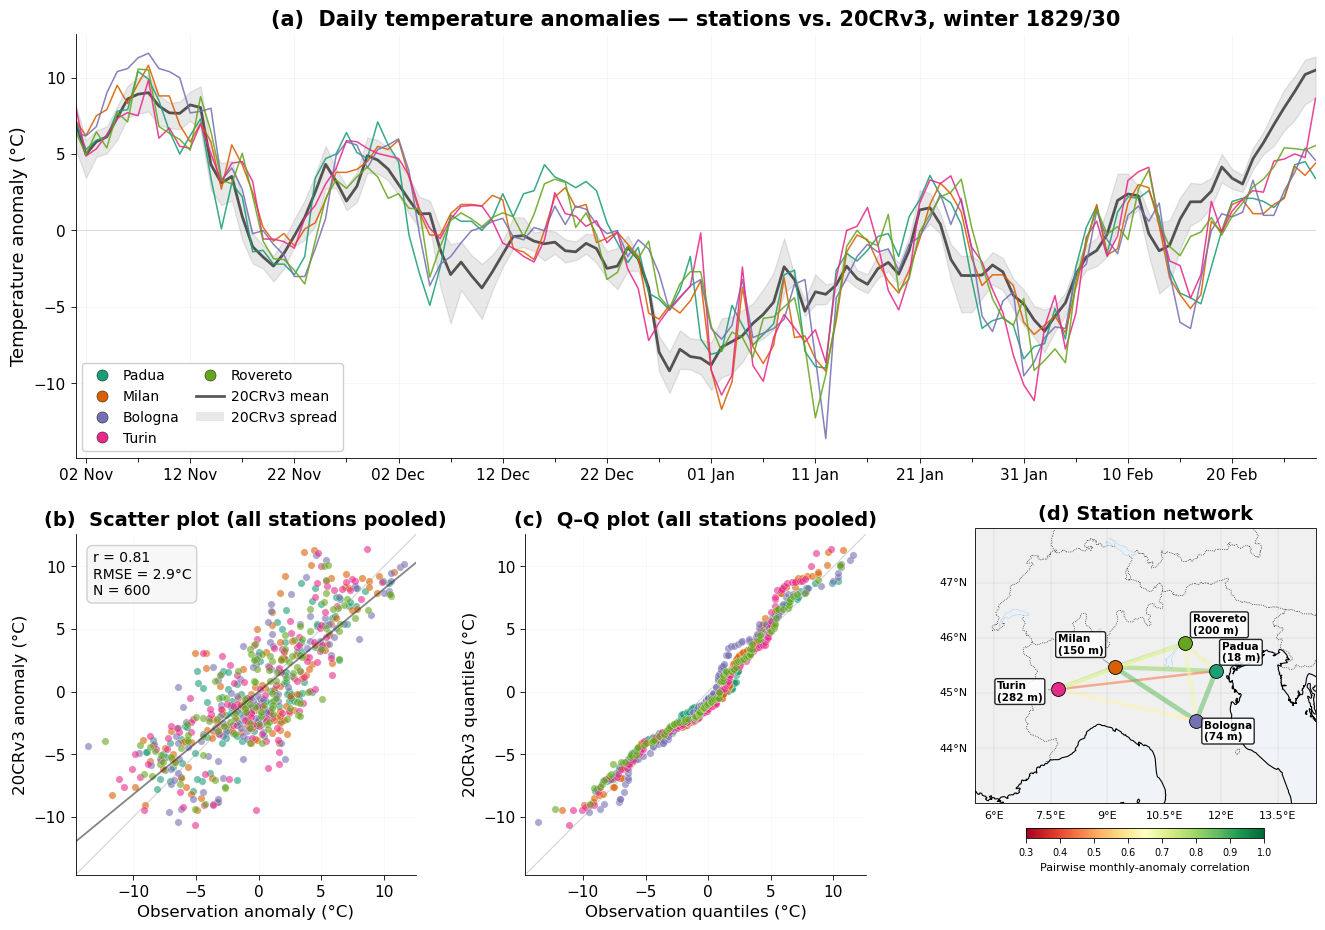

In [45]:
# ── 4. Figure ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 3, hspace=0.18, wspace=0.32, height_ratios=[1.2, 1])

# --- Panel (a): Time series of anomalies ---
ax_ts = fig.add_subplot(gs[0, :])

for name, s in stations.items():
    ax_ts.plot(s['obs_anom'].index, s['obs_anom'].values, '-', 
               color=colors_sta[name], linewidth=1.1, alpha=0.88, label=f'{name} obs')

# 20CRv3: average the anomalies from all 4 grid cells for a single reference line
# 20CRv3 envelope (min/max shading) + mean line
cr_anoms_all = pd.DataFrame({n: s['cr_anom'] for n, s in stations.items()})
cr_mean_anom = cr_anoms_all.mean(axis=1)
cr_min = cr_anoms_all.min(axis=1)
cr_max = cr_anoms_all.max(axis=1)

unibern = "#241f1f"
ax_ts.fill_between(cr_mean_anom.index, cr_min.values, cr_max.values,
                    color=unibern, alpha=0.10, label='20CRv3 spread (4 cells)', zorder=0)
ax_ts.plot(cr_mean_anom.index, cr_mean_anom.values, '-', color=unibern, linewidth=2,
           alpha=0.75, label='20CRv3 mean', zorder=1)
ax_ts.set_xlim([cr_mean_anom.index[0], cr_mean_anom.index[-1]])
ax_ts.axhline(0, color='k', ls='-', alpha=0.15, lw=0.5)
ax_ts.set_ylabel('Temperature anomaly (°C)', fontsize=13)
ax_ts.set_title('(a)  Daily temperature anomalies — stations vs. 20CRv3, winter 1829/30',
                fontsize=15, fontweight='semibold')
# ax_ts.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.08),
#              frameon=False, columnspacing=1.5)
ax_ts.grid(True, alpha=0.15, lw=0.5)

leg_handles = []
for name in stations:
    leg_handles.append(Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors_sta[name], markersize=8,
                              markeredgecolor='k', markeredgewidth=0.3,
                              label=name, linestyle='None'))
leg_handles.append(Line2D([0], [0], color=unibern, lw=2, alpha=0.75, label='20CRv3 mean'))
leg_handles.append(plt.Rectangle((0, 0), 1, 1, fc=unibern, alpha=0.10,
                                  edgecolor='none', label='20CRv3 spread'))

ax_ts.legend(handles=leg_handles, fontsize=10, loc='lower left',
             ncol=2, framealpha=0.92, edgecolor='#cccccc',
             columnspacing=1.2, handletextpad=0.5)


# Replace the x-axis formatting block with:
ax_ts.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax_ts.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_ts.tick_params(axis='x', which='minor', length=3)

# --- Pool all station anomalies for scatter and QQ ---
all_obs_anom = []
all_cr_anom = []
for name, s in stations.items():
    all_obs_anom.append(s['obs_anom'].values)
    all_cr_anom.append(s['cr_anom'].values)

all_obs = np.concatenate(all_obs_anom)
all_cr  = np.concatenate(all_cr_anom)

r_val = np.corrcoef(all_obs, all_cr)[0, 1]
rmse  = np.sqrt(np.mean((all_obs - all_cr)**2))
lims = [min(all_obs.min(), all_cr.min()) - 1, max(all_obs.max(), all_cr.max()) + 1]

# --- Panel (b): Scatter plot ---
ax_sc = fig.add_subplot(gs[1, 0])

for name, s in stations.items():
    ax_sc.scatter(s['obs_anom'], s['cr_anom'], s=28, alpha=0.6, 
                  color=colors_sta[name], edgecolor='white', linewidth=0.3, label=name)

ax_sc.plot(lims, lims, '-', color='#aaaaaa', alpha=0.5, lw=0.8, zorder=0)

# Regression line
slope, intercept = np.polyfit(all_obs, all_cr, 1)
xfit = np.linspace(lims[0], lims[1], 50)
ax_sc.plot(xfit, slope*xfit + intercept, '-', color='#333333', alpha=0.6, lw=1.3)

ax_sc.set_xlim(lims); ax_sc.set_ylim(lims)
ax_sc.set_aspect('equal')
ax_sc.set_xlabel('Observation anomaly (°C)', fontsize=12)
ax_sc.set_ylabel('20CRv3 anomaly (°C)', fontsize=12)
ax_sc.set_title('(b)  Scatter plot (all stations pooled)', fontsize=14, fontweight='semibold')
ax_sc.text(0.05, 0.95,
           f'r = {r_val:.2f}\nRMSE = {rmse:.1f}°C\nN = {len(all_obs)}',
           transform=ax_sc.transAxes, fontsize=10, va='top',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='#f7f7f7',
                     edgecolor='#cccccc', alpha=0.9))
# ax_sc.legend(fontsize=9, loc='lower right', framealpha=0.9, edgecolor='#cccccc')
ax_sc.grid(True, alpha=0.1, lw=0.5)

# --- Panel (c): Q-Q plot ---
ax_qq = fig.add_subplot(gs[1, 1])

for name, s in stations.items():
    obs_q = np.sort(s['obs_anom'].values)
    cr_q = np.sort(s['cr_anom'].values)
    ax_qq.scatter(obs_q, cr_q, s=28, alpha=0.6, color=colors_sta[name],
                  edgecolor='white', linewidth=0.3, label=name)
ax_qq.plot(lims, lims, '-', color='#aaaaaa', alpha=0.5, lw=0.8, zorder=0)
ax_qq.set_xlim(lims); ax_qq.set_ylim(lims)
ax_qq.set_aspect('equal')
ax_qq.set_xlabel('Observation quantiles (°C)', fontsize=12)
ax_qq.set_ylabel('20CRv3 quantiles (°C)', fontsize=12)
ax_qq.set_title('(c)  Q–Q plot (all stations pooled)', fontsize=14, fontweight='semibold')
# ax_qq.legend(fontsize=9, loc='lower right', framealpha=0.9, edgecolor='#cccccc')
ax_qq.grid(True, alpha=0.1, lw=0.5)

# --- Panel (d): Station map ---

# (keep the to_monthly_anom, haversine, station_coords, and pairs_df 
#  computation from before — that part is the same)

ax_map = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())
ax_map.set_extent([5.5, 14.5, 43.0, 48.0], crs=ccrs.PlateCarree())
ax_map.set_aspect('auto')

# Background
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax_map.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='none', zorder=0)
ax_map.add_feature(cfeature.OCEAN, facecolor='#f0f4f8', zorder=0)
ax_map.add_feature(cfeature.LAKES, facecolor='#e8f0f8', edgecolor='#aaccee', linewidth=0.3)

# Pairwise correlation lines
cmap_map = plt.cm.RdYlGn
for _, r in pairs_df.iterrows():
    color = cmap_map((r['corr'] - 0.3) / 0.7)
    lw = max(1, 4 * r['corr'])
    ax_map.plot([r['lon1'], r['lon2']], [r['lat1'], r['lat2']],
                color=color, linewidth=lw, alpha=0.55, zorder=2,
                transform=ccrs.PlateCarree())

# Station dots + labels
label_offsets = {
    'Padua': (0.15, 0.18), 'Milan': (-1.5, 0.25), 'Bologna': (0.2, -0.35),
    'Turin': (-1.6, -0.2), 'Rovereto': (0.2, 0.18),
}
for name, (slat, slon, alt) in station_coords.items():
    c = colors_sta.get(name, 'gray')
    ax_map.plot(slon, slat, 'o', color=c, markersize=10,
                markeredgecolor='k', markeredgewidth=0.6, zorder=5,
                transform=ccrs.PlateCarree())
    dx, dy = label_offsets.get(name, (0.2, 0.15))
    ax_map.annotate(f"{name}\n({alt} m)", xy=(slon, slat),
                    xytext=(slon + dx, slat + dy),
                    fontsize=7.5, fontweight='bold', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
                    if abs(dx) > 1 else None,
                    transform=ccrs.PlateCarree())

sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=plt.Normalize(0.3, 1.0))
cb = plt.colorbar(sm, ax=ax_map, orientation='horizontal', pad=0.07, shrink=0.7, aspect=25)
cb.set_label('Pairwise monthly-anomaly correlation', fontsize=8)

gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.3)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

cb.ax.tick_params(labelsize=7)
ax_map.set_title('(d) Station network', fontsize=14, fontweight='semibold')

###################### save fig #####################################

plt.savefig('image/validation_anomalies_combined.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('image/validation_anomalies_combined.pdf', bbox_inches='tight', facecolor='white')
print("✓ Saved")

print(f"\n=== POOLED ANOMALY STATS ===")
print(f"  r = {r_val:.3f}")
print(f"  RMSE = {rmse:.2f}°C")
print(f"  bias = {bias:+.3f}°C")
print(f"  N = {len(all_obs)} days (4 stations × 120)")

# Per-station anomaly stats
print(f"\n=== PER-STATION ANOMALY STATS ===")
for name, s in stations.items():
    o, c = s['obs_anom'].values, s['cr_anom'].values
    r = np.corrcoef(o, c)[0,1]
    rmse_s = np.sqrt(np.mean((o-c)**2))
    bias_s = np.mean(c - o)
    print(f"  {name:12s}: r={r:.3f}  RMSE={rmse_s:.2f}°C  bias={bias_s:+.2f}°C")

In [39]:
pairs_df

,station1,station2,dist_km,corr,lat1,lon1,lat2,lon2
0,Padua,Milan,209.248729,0.803496,45.400,11.870,45.470,9.190
1,Padua,Bologna,108.118092,0.859143,45.400,11.870,44.500,11.350
2,Padua,Turin,329.818325,0.446676,45.400,11.870,45.068,7.684
3,Padua,Rovereto,84.578418,0.686384,45.400,11.870,45.900,11.050
4,Milan,Bologna,201.215523,0.860554,45.470,9.190,44.500,11.350
5,Milan,Turin,126.044368,0.760423,45.470,9.190,45.068,7.684
6,Milan,Rovereto,152.188199,0.759438,45.470,9.190,45.900,11.050
7,Bologna,Turin,296.114862,0.623304,44.500,11.350,45.068,7.684
8,Bologna,Rovereto,157.437127,0.677114,44.500,11.350,45.900,11.050
9,Turin,Rovereto,278.215882,0.674409,45.068,7.684,45.900,11.050
